# Grammar Scoring Engine for Spoken English

**SHL Hiring Assessment 2026 · Yuvraj · Kaggle `achyutayuvraj` · GitHub `YUVRAJ-NOVA`**

Given a 45 to 60 second recording of someone speaking English, predict the grammar score (MOS Likert, 0 to 5) that human raters gave it.

## Executive summary

| | |
|---|---|
| **Final model** | Average of four regression heads on frozen embeddings: WavLM-Large (layer 21), Whisper-large-v3 encoder (layer 30), Qwen2.5-7B-Instruct and Qwen2.5-14B-Instruct mean-pooled over the ASR transcript (layers 16 and 21). Each head is the average of a ridge regression and an RBF-SVR. Silent, noise-only recordings are scored 0 by an acoustic rule. |
| **Training RMSE** (in-sample, required) | **0.256** on the 732 speech recordings (Pearson 0.976); 0.250 on all 769 including the zero rule |
| **Cross-validated** (three fresh group-fold schemes, never used for any choice) | RMSE ≈ **0.538**, Pearson ≈ **0.853** (test-mix weighted: RMSE 0.538, Pearson 0.840) |
| **Public leaderboard** | 0.3700 for this model; 0.3662 for the hedge that also uses text features. Single-feature baseline: 0.4182 |

**What I think matters most in this notebook**

1. **The validation design.** Random K-fold leaks: near-duplicate speakers or recording sessions end up on both sides of the split, and it made CV look about 0.02 Pearson better than it really was. I grouped recordings by acoustic similarity, checked that validation folds look as "new" as the test set does, and weighted the metric to match the test mix of 45 s and 60 s clips (66 % of test is 45 s, but only 20 % of train).
2. **A rule fixed before looking at results.** Every candidate change had to beat the current model on three fresh fold schemes, by a pre-set margin, without hurting the selection folds. Several reasonable ideas failed that rule, and Section 9 reports them.
3. **Honesty about uncertainty.** The public leaderboard uses about 130 recordings, so differences below about 0.01 are noise. I picked the final model by cross-validation, not by the public score.
4. **A fairness finding I did not expect.** Among speakers the raters gave the same score, the model scores those with clearer audio for the ASR (higher Whisper confidence) and faster speech higher. The model never sees these features, but its embeddings pick them up. Speakers with an unfamiliar accent or a poor microphone may therefore be under-scored. Section 11 measures it and Section 14 says what I would do about it.

**Contents**

1. Setup  ·  2. Optional feature extraction (GPU)  ·  3. Data and EDA  ·  4. Validation design  ·  5. Features and layer choice  ·  6. Model  ·  7. Results and training RMSE  ·  8. Ablations  ·  9. What did not work  ·  10. Error analysis  ·  11. Fairness and robustness  ·  12. Cost and deployment  ·  13. Submission  ·  14. Limitations and next steps

## 1. Setup

Feature extraction needs about 2.5 GPU hours (Kaggle T4 x2), so by default this notebook loads features that were extracted once and saved. Set `RUN_EXTRACTION = True` to rebuild every feature from the audio. All modelling below runs on CPU in about 10 minutes.

**Inputs when `RUN_EXTRACTION = False`** (outputs of my earlier notebooks, attached with *Add Input*): `shl-01-setup-eda` (audio metadata), `shl-05-baseline` (group folds used for selection), `shl-03-wavlm`, `shl-06-whisper-enc`, `shl-11-llm-views`, `shl-13-llm14`, and, only for the text-feature ablation, `shl-04-text-features` and `shl-09-llm`.

**Data policy:** no audio, transcript or embedding is printed or saved for sharing. Outputs are aggregate numbers and plots only.

In [1]:
import os, glob, json, re, gc, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedGroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.width', 220)
T_START = time.time()

RUN_EXTRACTION = False     # True: rebuild all features from audio (GPU T4 x2, internet on, ~2.5 h)
RUN_LAYER_SWEEP = True     # layer-by-layer CV curves (CPU, ~3 min)
SEED = 42

INPUT_ROOT = os.environ.get('SHL_INPUT_ROOT', '/kaggle/input')
WORK = os.environ.get('SHL_WORK', '/kaggle/working')
FEAT_DIR = f'{WORK}/features'
os.makedirs(FEAT_DIR, exist_ok=True)

def find(name, required=True):
    # freshly extracted features (FEAT_DIR) take priority over attached inputs
    local = glob.glob(f'{FEAT_DIR}/**/{name}', recursive=True)
    if local:
        return local[0]
    hits = sorted(glob.glob(f'{INPUT_ROOT}/**/{name}', recursive=True))
    if required:
        assert len(hits) == 1, f'{name}: expected exactly one file, found {hits}'
    return hits[0] if hits else None

BASE = os.path.dirname(find('train.csv'))
train = pd.read_csv(f'{BASE}/train.csv')
test = pd.read_csv(f'{BASE}/test.csv')
tr_uids = ['train/' + f for f in train.filename]
te_uids = ['test/' + f for f in test.filename]
ALL_UIDS = tr_uids + te_uids
assert len(set(ALL_UIDS)) == len(ALL_UIDS) == len(train) + len(test)
print('train', train.shape, '| test', test.shape, '| data folder:', BASE)

train (769, 2) | test (216, 2) | data folder: /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final


## 2. Optional: feature extraction from audio (GPU)

This section is skipped unless `RUN_EXTRACTION = True`. It is the same code as my experiment notebooks (`shl-01`, `shl-02`, `shl-03`, `shl-06`, `shl-11`, `shl-13`), collected in one place:

| Step | Model | Output | Time on T4 |
|---|---|---|---|
| Acoustic stats | librosa | duration, spectral flatness, dynamic range (zero rule) | ~3 min CPU |
| ASR with word timings | faster-whisper large-v3, disfluency-keeping prompt | transcripts | ~60 min |
| Self-supervised speech | microsoft/wavlm-large | mean and std of each layer | ~20 min |
| Speech encoder | openai/whisper-large-v3 encoder | mean and std of each layer | ~6 min |
| LLM on transcript | Qwen2.5-7B-Instruct fp16, rubric prompt | transcript-token mean of 6 layers | ~7 min |
| LLM on transcript | Qwen2.5-14B-Instruct 8-bit, same prompt | transcript-token mean of 6 layers | ~13 min |

Two design notes. The ASR prompt contains fillers and repetitions so that Whisper keeps disfluencies instead of tidying them up, which matters when the target is grammar. For the LLMs I do not use the generated answer as the feature; I average the hidden states over the transcript tokens while the model is reading them under a grammar rubric prompt, and a linear head learns what to read from them.

In [2]:
if RUN_EXTRACTION:
    import subprocess, sys, soundfile as sf, librosa, torch
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'faster-whisper', 'bitsandbytes'], check=True)
    os.environ.setdefault('HF_HOME', '/kaggle/temp/hf')
    assert torch.cuda.is_available(), 'set Accelerator to GPU T4 x2'
    SR = 16000

    # ---- 2a. acoustic statistics (zero rule and duration groups) ----
    def acoustic(uid):
        y, sr = librosa.load(f'{BASE}/{uid}', sr=SR, mono=True)
        rms = librosa.feature.rms(y=y, frame_length=1024, hop_length=256)[0] + 1e-9
        db = 20 * np.log10(rms)
        flat = librosa.feature.spectral_flatness(y=y, n_fft=1024, hop_length=256)[0]
        iv = librosa.effects.split(y, top_db=30)
        return dict(uid=uid, split=uid.split('/')[0], filename=uid.split('/')[1], duration=len(y) / SR,
                    rms_db=float(20 * np.log10(np.sqrt(np.mean(y ** 2)) + 1e-12)),
                    speech_ratio=float(sum(e - s for s, e in iv) / max(len(y), 1)),
                    db_p10=float(np.percentile(db, 10)), dyn_range=float(np.percentile(db, 90) - np.percentile(db, 10)),
                    flat_mean=float(flat.mean()))
    pd.DataFrame([acoustic(u) for u in ALL_UIDS]).to_csv(f'{FEAT_DIR}/audio_meta.csv', index=False)
    print('acoustic stats saved')

    # ---- 2b. ASR with word timestamps ----
    from faster_whisper import WhisperModel
    asr_model = WhisperModel('large-v3', device='cuda', compute_type='float16')
    PROMPT = "Umm, let me think like, hmm... Okay, here's what I'm, like, thinking. I I was going to, uh, say that."
    ASR_OUT = f'{FEAT_DIR}/asr_raw'
    os.makedirs(ASR_OUT, exist_ok=True)
    for i, uid in enumerate(ALL_UIDS):
        y, sr = sf.read(f'{BASE}/{uid}', dtype='float32')
        y = y.mean(1) if y.ndim > 1 else y
        segs, info = asr_model.transcribe(y, language='en', task='transcribe', beam_size=5,
                                          condition_on_previous_text=False, initial_prompt=PROMPT,
                                          word_timestamps=True, vad_filter=False)
        out = [dict(start=s.start, end=s.end, text=s.text, avg_logprob=s.avg_logprob, no_speech_prob=s.no_speech_prob,
                    compression_ratio=s.compression_ratio,
                    words=[dict(w=w.word, s=w.start, e=w.end, p=w.probability) for w in (s.words or [])]) for s in segs]
        json.dump(dict(uid=uid, duration=info.duration, segments=out), open(f'{ASR_OUT}/{uid.replace("/", "__")}.json', 'w'))
        if (i + 1) % 100 == 0:
            print('asr', i + 1)
    del asr_model; gc.collect(); torch.cuda.empty_cache()

    # ---- 2c. WavLM-Large: mean and std of every layer ----
    from transformers import AutoModel
    wl = AutoModel.from_pretrained('microsoft/wavlm-large').to('cuda').eval()
    M = np.zeros((len(ALL_UIDS), 25, 1024), np.float16); S = np.zeros_like(M)
    for i, uid in enumerate(ALL_UIDS):
        y, sr = sf.read(f'{BASE}/{uid}', dtype='float32')
        y = y.mean(1) if y.ndim > 1 else y
        y = (y - y.mean()) / (y.std() + 1e-7)
        with torch.inference_mode(), torch.autocast('cuda', dtype=torch.float16):
            hs = wl(torch.from_numpy(y)[None].to('cuda'), output_hidden_states=True).hidden_states
        H = torch.stack([h[0].float() for h in hs], 0)
        M[i], S[i] = H.mean(1).cpu().numpy(), H.std(1).cpu().numpy()
    np.save(f'{FEAT_DIR}/wavlm_large_mean.npy', M); np.save(f'{FEAT_DIR}/wavlm_large_std.npy', S)
    pd.Series(ALL_UIDS).to_csv(f'{FEAT_DIR}/wavlm_uids.csv', index=False, header=['uid'])
    del wl; gc.collect(); torch.cuda.empty_cache()
    print('wavlm saved', M.shape)

    # ---- 2d. Whisper-large-v3 encoder: mean and std over real-audio frames ----
    from transformers import WhisperModel as HFWhisper, WhisperFeatureExtractor
    fe = WhisperFeatureExtractor.from_pretrained('openai/whisper-large-v3')
    full = HFWhisper.from_pretrained('openai/whisper-large-v3')
    enc = full.encoder.half().to('cuda').eval(); del full; gc.collect()
    CH, FRAME = 30 * SR, 320
    M = np.zeros((len(ALL_UIDS), 33, 1280), np.float16); S = np.zeros_like(M)
    for i, uid in enumerate(ALL_UIDS):
        y, sr = sf.read(f'{BASE}/{uid}', dtype='float32')
        y = y.mean(1) if y.ndim > 1 else y
        chunks = [y[k:k + CH] for k in range(0, len(y), CH)]
        if len(chunks) > 1 and len(chunks[-1]) < 2 * SR:
            chunks = chunks[:-1]
        feats = fe(chunks, sampling_rate=SR, return_tensors='pt').input_features.to('cuda').half()
        with torch.inference_mode():
            H = torch.stack(enc(feats, output_hidden_states=True).hidden_states, 0)
        s1 = s2 = None; n = 0
        for b, c in enumerate(chunks):
            nv = max(1, min(1500, (len(c) + FRAME - 1) // FRAME))
            Hb = H[:, b, :nv].float()
            s1 = Hb.sum(1) if s1 is None else s1 + Hb.sum(1)
            s2 = (Hb ** 2).sum(1) if s2 is None else s2 + (Hb ** 2).sum(1)
            n += nv
        mu = s1 / n
        M[i], S[i] = mu.cpu().numpy(), (s2 / n - mu ** 2).clamp_min(0).sqrt().cpu().numpy()
    np.save(f'{FEAT_DIR}/whisper_enc_mean.npy', M); np.save(f'{FEAT_DIR}/whisper_enc_std.npy', S)
    pd.Series(ALL_UIDS).to_csv(f'{FEAT_DIR}/whisper_enc_uids.csv', index=False, header=['uid'])
    del enc; gc.collect(); torch.cuda.empty_cache()
    print('whisper encoder saved', M.shape)

    # ---- 2e. Qwen2.5 7B and 14B: hidden states mean-pooled over the transcript tokens ----
    from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
    texts = {}
    for u in ALL_UIDS:
        r = json.load(open(f'{ASR_OUT}/{u.replace("/", "__")}.json'))
        texts[u] = re.sub(r'\s+', ' ', ' '.join(s['text'].strip() for s in r['segments'])).strip()
    SYSTEM = 'You are an expert examiner of spoken English grammar.'
    Q3 = '"' * 3
    MARK = 'Transcript:\n' + Q3 + '\n'
    TAIL = 'Answer with a single digit from 1 to 5 and nothing else.'
    INTRO = ('Below is an automatic speech-recognition transcript of a 45 to 60 second spoken response. '
             'The transcript comes from speech recognition, so ignore capitalization and punctuation; '
             'repetitions and false starts are real features of the speech.\n\n')
    RUBRIC = '''1: The speech struggles with proper sentence structure and syntax, with limited control over simple grammatical structures and memorized sentence patterns.
2: Limited understanding of sentence structure and syntax. Simple structures are used, but basic sentence-structure and grammatical mistakes are consistent. Sentences may be left incomplete.
3: Decent grasp of sentence structure but errors in grammatical structure, or decent grasp of grammatical structure but errors in sentence syntax and structure.
4: Strong understanding of sentence structure and syntax, with consistently good control of grammar. Occasional errors are generally minor, do not cause misunderstanding, and most can be self-corrected.
5: High grammatical accuracy and adept control of complex grammar. Grammar is used accurately and effectively, with seldom any noticeable mistakes. Complex structures are handled well and the speaker corrects themselves when necessary.'''
    TASK = ("Rate ONLY the speaker's grammar (sentence structure, syntax, grammatical accuracy and control of complex structures). "
            'Do not rate vocabulary, pronunciation, fluency or the quality of the ideas.\n\nGrammar score rubric:\n' + RUBRIC)

    def llm_pool(model_id, layers_frac, out_name, uid_name, eight_bit):
        tok = AutoTokenizer.from_pretrained(model_id)
        kw = dict(device_map='auto')
        if eight_bit:
            kw['quantization_config'] = BitsAndBytesConfig(load_in_8bit=True)
        model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.float16, **kw).eval()
        NL = model.config.num_hidden_layers
        layers = [int(round(f * NL)) for f in layers_frac]
        P = np.zeros((len(ALL_UIDS), len(layers), model.config.hidden_size), np.float16)
        for i, u in enumerate(ALL_UIDS):
            text = texts[u]
            user = INTRO + TASK + '\n\n' + MARK + text + '\n' + Q3 + '\n\n' + TAIL
            prompt = tok.apply_chat_template([{'role': 'system', 'content': SYSTEM}, {'role': 'user', 'content': user}],
                                             tokenize=False, add_generation_prompt=True)
            enc_ = tok(prompt, return_tensors='pt', return_offsets_mapping=True)
            offs = enc_.pop('offset_mapping')[0]
            a = prompt.rfind(MARK) + len(MARK); b = a + len(text)
            m = (offs[:, 0] >= a) & (offs[:, 1] <= b) & (offs[:, 1] > offs[:, 0])
            idx = torch.nonzero(m).squeeze(-1).to(model.device)
            with torch.inference_mode():
                out = model(**enc_.to(model.device), output_hidden_states=True, use_cache=False)
            P[i] = np.clip(torch.stack([out.hidden_states[L][0].index_select(0, idx).float().mean(0) for L in layers], 0)
                           .cpu().numpy(), -6e4, 6e4)
        np.save(f'{FEAT_DIR}/{out_name}', P)
        pd.Series(ALL_UIDS).to_csv(f'{FEAT_DIR}/{uid_name}', index=False, header=['uid'])
        del model; gc.collect(); torch.cuda.empty_cache()
        print(model_id, 'pooled layers', layers, P.shape)

    FRAC = (0.21, 0.32, 0.43, 0.57, 0.71, 0.86)       # layers 6, 9, 12, 16, 20, 24 of 28 for the 7B model
    llm_pool('Qwen/Qwen2.5-7B-Instruct', FRAC, 'llm_rubric_meanpool.npy', 'llm_views_uids.csv', eight_bit=False)
    llm_pool('Qwen/Qwen2.5-14B-Instruct', FRAC, 'llm14_meanpool.npy', 'llm14_uids.csv', eight_bit=True)
else:
    print('RUN_EXTRACTION is False: using the features attached as inputs')

RUN_EXTRACTION is False: using the features attached as inputs


## 3. Data and exploratory analysis

Three findings shaped everything that follows:

* **37 training files (4.8 %) are labelled 0 and contain no speech**, only noise. They are not "very bad grammar"; they are a different kind of input. A two-feature acoustic rule (high spectral flatness and low dynamic range) separates them perfectly on train and fires on none of the 216 test files. I score them 0 with the rule and train every model on the 732 speech files only.
* **The duration mix shifts between train and test.** 45-second clips are 20 % of train but 66 % of test. Scores also differ by group (45 s clips average lower). I weight every validation metric by the test share of each group (45 s: ×3.22, 60 s: ×0.40), so CV estimates the test mix rather than the train mix.
* **Labels are discrete** (mostly 2.0 to 5.0 in half steps) with a mean of 3.48 on speech files. Predicting the mean gives a test-weighted RMSE of 0.97.

zero rule on train: fires on 37 files | true zeros caught 37 of 37 | false alarms 0
zero rule on test : fires on 0 of 216 files
test-mix weights per duration group: {'dur_45s': 3.22, 'dur_60s': 0.404, 'short_lt40': 0.949}
            train share  test share  train mean label (speech only)
dur_45s           0.204       0.657                           3.091
dur_60s           0.757       0.306                           3.589
short_lt40        0.039       0.037                           3.500


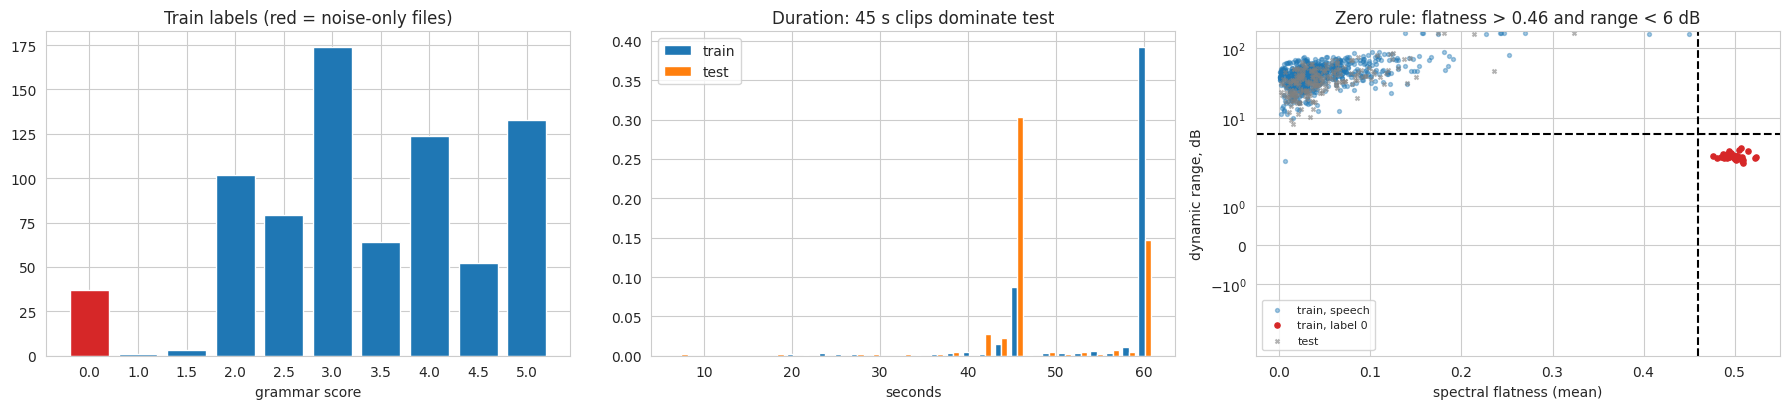

In [3]:
meta = pd.read_csv(find('audio_meta.csv'))
if 'uid' not in meta.columns:
    meta['uid'] = meta.split + '/' + meta.filename
meta = meta.set_index('uid')

def dur_group(d):
    return np.where(d < 40, 'short_lt40', np.where(d < 52, 'dur_45s', 'dur_60s'))

y_all = train.label.values.astype(float)
dur_tr = meta.loc[tr_uids, 'duration'].values
dur_te = meta.loc[te_uids, 'duration'].values
grp = dur_group(dur_tr)
te_grp = dur_group(dur_te)

zero_rule = lambda d: ((d.flat_mean > 0.46) & (d.dyn_range < 6)).values
rule_tr = zero_rule(meta.loc[tr_uids])
rule_te = zero_rule(meta.loc[te_uids])
is_zero = (y_all == 0)
print(f'zero rule on train: fires on {rule_tr.sum()} files | true zeros caught {int((rule_tr & is_zero).sum())} of {int(is_zero.sum())} '
      f'| false alarms {int((rule_tr & ~is_zero).sum())}')
print(f'zero rule on test : fires on {rule_te.sum()} of {len(te_uids)} files')

nz = ~is_zero
y = y_all
mix_te = pd.Series(te_grp).value_counts(normalize=True)
mix_tr = pd.Series(grp).value_counts(normalize=True)
W_GRP = (mix_te / mix_tr).to_dict()
w = np.array([W_GRP[g] for g in grp])
print('test-mix weights per duration group:', {k: round(v, 3) for k, v in W_GRP.items()})

tab = pd.DataFrame({'train share': mix_tr, 'test share': mix_te}).round(3)
tab['train mean label (speech only)'] = pd.Series(y[nz]).groupby(grp[nz]).mean().round(3)
print(tab)

fig, ax = plt.subplots(1, 3, figsize=(18, 4.2))
vc = pd.Series(y).value_counts().sort_index()
ax[0].bar(vc.index.astype(str), vc.values, color=['tab:red' if v == 0 else 'tab:blue' for v in vc.index])
ax[0].set_title('Train labels (red = noise-only files)'); ax[0].set_xlabel('grammar score')
ax[1].hist([dur_tr, dur_te], bins=30, label=['train', 'test'], density=True)
ax[1].set_title('Duration: 45 s clips dominate test'); ax[1].set_xlabel('seconds'); ax[1].legend()
m_ = meta.loc[tr_uids]
ax[2].scatter(m_.flat_mean[~is_zero], m_.dyn_range[~is_zero], s=8, alpha=0.4, label='train, speech')
ax[2].scatter(m_.flat_mean[is_zero], m_.dyn_range[is_zero], s=14, color='tab:red', label='train, label 0')
ax[2].scatter(meta.loc[te_uids].flat_mean, meta.loc[te_uids].dyn_range, s=8, marker='x', color='gray', alpha=0.6, label='test')
ax[2].axvline(0.46, ls='--', c='k'); ax[2].axhline(6, ls='--', c='k')
ax[2].set_yscale('symlog'); ax[2].set_xlabel('spectral flatness (mean)'); ax[2].set_ylabel('dynamic range, dB')
ax[2].set_title('Zero rule: flatness > 0.46 and range < 6 dB'); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Validation design

### 4.1 The metric I optimise

The leaderboard combines Pearson correlation and RMSE into one number. I work with **proxy = (RMSE + 1 − Pearson) / 2**, computed on test-mix-weighted CV. For the first five versions the public score matched this proxy within ±0.01; the last two came in 0.012 to 0.017 worse than CV, which fits the leaderboard noise (about 130 files) plus some optimism from choosing among many candidates. It is a working hypothesis, not a confirmed formula, so I report RMSE and Pearson separately throughout.

### 4.2 Why not random K-fold

With random folds, the nearest training neighbour of a 60 s validation file is far more similar (cosine 0.82 on WavLM layer 4) than the nearest neighbour of a test file (0.46). Some recordings share a speaker or session, and random folds put them on both sides. That inflates CV.

I therefore cluster recordings on early WavLM layers (0, 2, 4; mean and std; these layers carry speaker and channel information, not content) and keep each cluster inside one fold, stratified by label bin and duration group. The check below shows the fix: with group folds, validation files are about as far from the training set as test files are.

### 4.3 Selection folds and fresh folds

* **Selection folds** `g250` and `g120` (250 and 120 clusters): all layer choices and model comparisons during development.
* **Fresh folds** A, B, C (different layers, cluster counts and seeds): built later and used only to accept or reject changes. A change was kept only if it improved all three fresh schemes, by at least 0.003 on average, and did not hurt the selection folds. The threshold was fixed before the results were seen.

In [4]:
def load_emb(emb_file, uid_file):
    E = np.load(find(emb_file), mmap_mode='r')
    ids = pd.read_csv(find(uid_file)).uid.tolist()
    ix = {u: i for i, u in enumerate(ids)}
    return E, np.array([ix[u] for u in tr_uids]), np.array([ix[u] for u in te_uids])

EW, w_tr, w_te = load_emb('wavlm_large_mean.npy', 'wavlm_uids.csv')
ES = np.load(find('wavlm_large_std.npy'), mmap_mode='r')
EWtr = np.asarray(EW[w_tr], dtype=np.float32)
EStr = np.asarray(ES[w_tr], dtype=np.float32)
n_tr = len(tr_uids)
idx_nz = np.where(nz)[0]
ybin = np.digitize(y, [2.25, 3.25, 4.25])
strat = ybin * 2 + (grp == 'dur_60s').astype(int)

# random folds (notebook 1), kept only to show the leakage
bucket = pd.cut(train.label, [-0.1, 0.1, 2.25, 3.25, 4.25, 5.1], labels=False)
dg2 = np.where(grp == 'dur_60s', 'g60', 'g45')
strat_r = np.where(is_zero, 'zero', bucket.astype(str) + '_' + dg2)
rand = np.zeros(n_tr, int)
for k, (_, va) in enumerate(RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED).split(train, strat_r)):
    if k < 5:
        rand[va] = k

# selection folds g120 / g250 (notebook 5): clusters on WavLM layers 0, 2, 4
G = np.hstack([EWtr[:, L] for L in (0, 2, 4)] + [EStr[:, L] for L in (0, 2, 4)])
sc = StandardScaler().fit(G[nz])
Z = PCA(n_components=50, random_state=SEED).fit(sc.transform(G[nz])).transform(sc.transform(G))
rng = np.random.RandomState(SEED)
SELF = {}
for k in [30, 60, 120, 250]:
    fold = rng.randint(0, 5, n_tr)
    if k in (120, 250):
        cl = AgglomerativeClustering(n_clusters=k, metric='cosine', linkage='average').fit_predict(Z[nz])
        for f, (_, va) in enumerate(StratifiedGroupKFold(5, shuffle=True, random_state=SEED).split(idx_nz, strat[nz], groups=cl)):
            fold[idx_nz[va]] = f
        SELF[f'g{k}'] = fold
fg_path = find('folds_group.csv', required=False)
if fg_path:
    fg = pd.read_csv(fg_path).set_index('uid').reindex(tr_uids)
    for c in ['g250', 'g120']:
        same = float((fg[c].values[nz] == SELF[c][nz]).mean())
        print(f'{c}: rebuilt folds agree with the saved development folds on {same:.1%} of speech files')
        SELF[c] = fg[c].values.astype(int)       # always score on the exact folds used during development

# fresh folds A, B, C (notebook 15)
def make_folds(layers, k, seed):
    G_ = np.hstack([EWtr[:, list(layers)].reshape(n_tr, -1), EStr[:, list(layers)].reshape(n_tr, -1)])
    sc_ = StandardScaler().fit(G_[nz])
    Z_ = PCA(n_components=50, random_state=seed).fit(sc_.transform(G_[nz])).transform(sc_.transform(G_))
    cl = AgglomerativeClustering(n_clusters=k, metric='cosine', linkage='average').fit_predict(Z_[nz])
    fold = np.random.RandomState(seed).randint(0, 5, n_tr)
    for f, (_, va) in enumerate(StratifiedGroupKFold(5, shuffle=True, random_state=seed).split(idx_nz, strat[nz], groups=cl)):
        fold[idx_nz[va]] = f
    return fold

FOLDS = {n: make_folds(*a) for n, a in {'A': ((0, 2, 4), 180, 7), 'B': ((1, 3, 5), 90, 11), 'C': ((2, 4, 6), 250, 23)}.items()}
FOLDS.update(SELF)
FRESH, SEL = ['A', 'B', 'C'], ['g250', 'g120']
ALL_S = FRESH + SEL
print('validation fold sizes (speech files):', {s: np.bincount(FOLDS[s][nz], minlength=5).tolist() for s in ALL_S})

g250: rebuilt folds agree with the saved development folds on 100.0% of speech files
g120: rebuilt folds agree with the saved development folds on 100.0% of speech files
validation fold sizes (speech files): {'A': [126, 171, 166, 126, 143], 'B': [173, 136, 97, 189, 137], 'C': [136, 136, 126, 136, 198], 'g250': [159, 133, 153, 148, 139], 'g120': [147, 113, 159, 171, 142]}


        validation 45s  test 45s  validation 60s  test 60s
folds                                                     
random           0.559     0.510           0.822     0.465
A                0.464     0.506           0.472     0.462
B                0.433     0.501           0.456     0.460
C                0.467     0.506           0.479     0.462
g250             0.477     0.508           0.482     0.463
g120             0.450     0.506           0.463     0.462


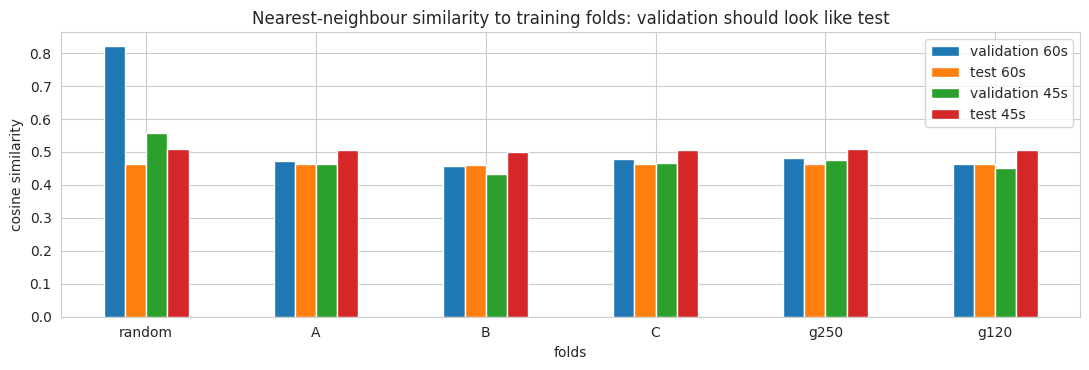

In [5]:
# leakage check: nearest-neighbour cosine similarity (WavLM layer 4) of validation files vs test files to the training folds
def l2n(Z_): return Z_ / (np.linalg.norm(Z_, axis=1, keepdims=True) + 1e-9)
X4tr, X4te = EWtr[:, 4], np.asarray(EW[w_te, 4], dtype=np.float32)

def nn_sim(fold):
    v, t = np.full(n_tr, np.nan), np.zeros((5, len(te_uids)))
    for f in range(5):
        va = fold == f
        ref, q = (~va) & nz, va & nz
        s_ = StandardScaler().fit(X4tr[ref])
        R_, Q_, T_ = (l2n(s_.transform(a)) for a in (X4tr[ref], X4tr[q], X4te))
        v[q], t[f] = (Q_ @ R_.T).max(1), (T_ @ R_.T).max(1)
    return v, t.mean(0)

rows = []
for name, fold in [('random', rand)] + [(s, FOLDS[s]) for s in ALL_S]:
    v, t = nn_sim(fold)
    r = {'folds': name}
    for g in ['dur_45s', 'dur_60s']:
        r[f'validation {g[4:]}'] = v[nz & (grp == g)].mean()
        r[f'test {g[4:]}'] = t[te_grp == g].mean()
    rows.append(r)
LEAK = pd.DataFrame(rows).set_index('folds').round(3)
print(LEAK)
ax = LEAK[['validation 60s', 'test 60s', 'validation 45s', 'test 45s']].plot.bar(figsize=(11, 3.8), rot=0)
ax.set_title('Nearest-neighbour similarity to training folds: validation should look like test')
ax.set_ylabel('cosine similarity'); plt.tight_layout(); plt.show()

## 5. Features and layer choice

Each input recording gives four frozen representations:

| Tag | Source | What it captures |
|---|---|---|
| `W` | WavLM-Large, layer 21, mean over time | how the speech sounds: rhythm, hesitation, pronunciation |
| `H` | Whisper-large-v3 encoder, layer 30, mean over time | speech features trained for recognition, close to what is being said |
| `M7` | Qwen2.5-7B, layer 16, mean over transcript tokens under a grammar rubric prompt | what an LLM "notices" while reading the transcript as a grammar examiner |
| `M14` | Qwen2.5-14B (8-bit), layer 21, same pooling | the same view from a larger model |

Layers were picked on the selection folds (the curves below). Middle-to-late layers win for every model: early layers describe sound, the very last ones are specialised for the pre-training objective. Mean-pooling the LLM over all transcript tokens beat the last-token state clearly (proxy 0.422 against 0.461 for the 7B model).

In [6]:
EH, h_tr, h_te = load_emb('whisper_enc_mean.npy', 'whisper_enc_uids.csv')
E7, s_tr, s_te = load_emb('llm_rubric_meanpool.npy', 'llm_views_uids.csv')
E14, q_tr, q_te = load_emb('llm14_meanpool.npy', 'llm14_uids.csv')
POOL7, POOL14 = [6, 9, 12, 16, 20, 24], [10, 15, 21, 27, 34, 41]
LAYER = {'W': 21, 'H': 30, 'M7': 16, 'M14': 21}
FEAT = {'W': (EWtr[:, 21], np.asarray(EW[w_te, 21], dtype=np.float32)),
        'H': (np.asarray(EH[h_tr, 30], dtype=np.float32), np.asarray(EH[h_te, 30], dtype=np.float32)),
        'M7': (np.asarray(E7[s_tr, POOL7.index(16)], dtype=np.float32), np.asarray(E7[s_te, POOL7.index(16)], dtype=np.float32)),
        'M14': (np.asarray(E14[q_tr, POOL14.index(21)], dtype=np.float32), np.asarray(E14[q_te, POOL14.index(21)], dtype=np.float32))}
for k, (a, b) in FEAT.items():
    assert np.isfinite(a).all() and np.isfinite(b).all(), k
    print(f'{k:4s} train {a.shape} test {b.shape}')

# ---------- metrics ----------
def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))
def pear(a, b): return float(np.corrcoef(a, b)[0, 1])
def wrmse(a, b, ww): return float(np.sqrt(np.sum(ww * (a - b) ** 2) / np.sum(ww)))
def wpear(a, b, ww):
    ma, mb = np.average(a, weights=ww), np.average(b, weights=ww)
    return float(np.sum(ww * (a - ma) * (b - mb)) / np.sqrt(np.sum(ww * (a - ma) ** 2) * np.sum(ww * (b - mb) ** 2)))
def score(oof):
    rm, pe = wrmse(y[nz], oof[nz], w[nz]), wpear(y[nz], oof[nz], w[nz])
    out = dict(proxy=(rm + 1 - pe) / 2, rmse_w=rm, pear_w=pe, rmse=rmse(y[nz], oof[nz]), pearson=pear(y[nz], oof[nz]))
    for g in ['dur_45s', 'dur_60s']:
        m = nz & (grp == g)
        out['pear_' + g[4:6]] = pear(y[m], oof[m])
    return out

# ---------- base learners (hyper-parameters fixed early, never tuned on the fresh folds) ----------
class Winsor(BaseEstimator, TransformerMixin):
    def __init__(self, lo=1, hi=99):
        self.lo, self.hi = lo, hi
    def fit(self, X, y=None):
        self.lo_, self.hi_ = np.percentile(X, self.lo, axis=0), np.percentile(X, self.hi, axis=0)
        return self
    def transform(self, X):
        return np.clip(X, self.lo_, self.hi_)

def ridge_wavlm(): return make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(1, 5, 9)))
def ridge_hid():   return make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(1, 6, 11)))
def ridge_text():  return make_pipeline(SimpleImputer(strategy='median'), Winsor(), StandardScaler(), RidgeCV(alphas=np.logspace(-1, 4, 12)))
def svr_head():    return make_pipeline(StandardScaler(), PCA(n_components=128, random_state=0), SVR(C=3.0, epsilon=0.2, gamma='scale'))
RIDGE = {'W': ridge_wavlm, 'H': ridge_hid, 'M7': ridge_hid, 'M14': ridge_hid, 'TL': ridge_text}

def oof_for(X, fold, maker):
    oof = np.full(n_tr, np.nan)
    for f in range(5):
        va = fold == f
        m = maker().fit(X[(~va) & nz], y[(~va) & nz])
        oof[va & nz] = np.clip(m.predict(X[va & nz]), 1, 5)
    return oof

W    train (769, 1024) test (216, 1024)
H    train (769, 1280) test (216, 1280)
M7   train (769, 3584) test (216, 3584)
M14  train (769, 5120) test (216, 5120)


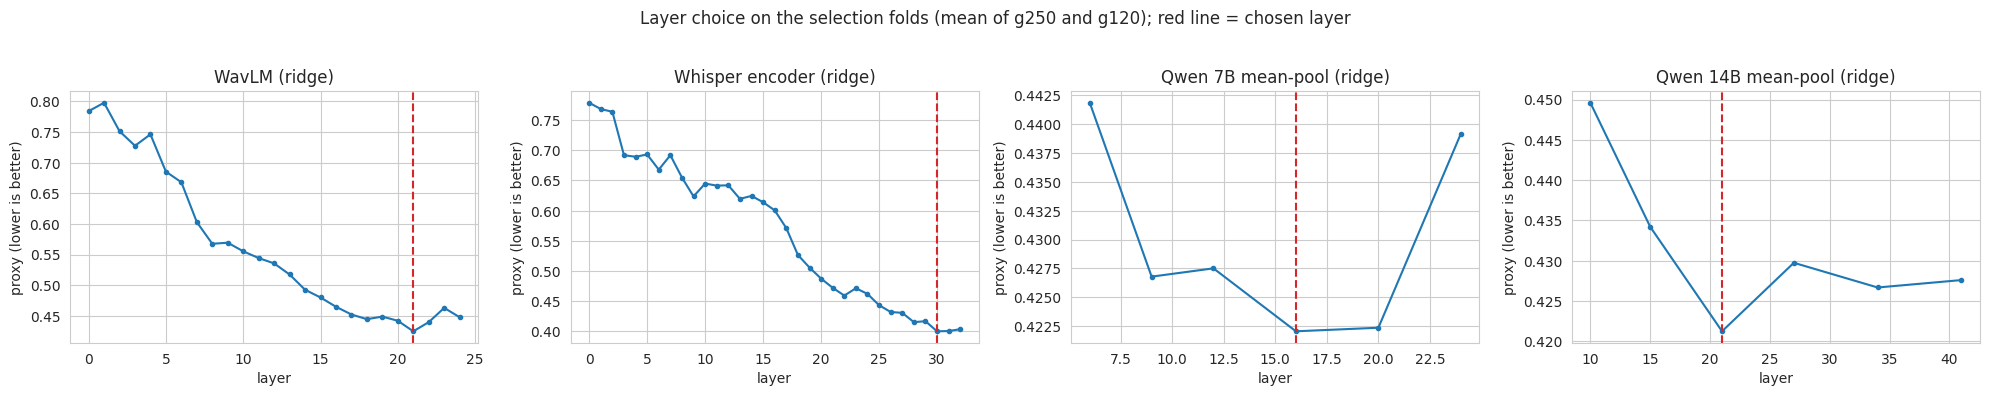

layer sweep took 3.0 min


In [7]:
if RUN_LAYER_SWEEP:
    t0 = time.time()
    def sweep(get, layers, maker):
        out = []
        for L in layers:
            X = get(L)
            out.append(np.mean([score(oof_for(X, FOLDS[s], maker))['proxy'] for s in SEL]))
        return np.array(out)
    SW = {'WavLM (ridge)': (range(25), sweep(lambda L: EWtr[:, L], range(25), ridge_wavlm), 21),
          'Whisper encoder (ridge)': (range(33), sweep(lambda L: np.asarray(EH[h_tr, L], dtype=np.float32), range(33), ridge_hid), 30),
          'Qwen 7B mean-pool (ridge)': (POOL7, sweep(lambda L: np.asarray(E7[s_tr, POOL7.index(L)], dtype=np.float32), POOL7, ridge_hid), 16),
          'Qwen 14B mean-pool (ridge)': (POOL14, sweep(lambda L: np.asarray(E14[q_tr, POOL14.index(L)], dtype=np.float32), POOL14, ridge_hid), 21)}
    fig, ax = plt.subplots(1, 4, figsize=(20, 3.8))
    for a, (name, (Ls, v, ch)) in zip(ax, SW.items()):
        a.plot(list(Ls), v, marker='o', ms=3)
        a.axvline(ch, ls='--', c='tab:red'); a.set_title(name); a.set_xlabel('layer'); a.set_ylabel('proxy (lower is better)')
    plt.suptitle('Layer choice on the selection folds (mean of g250 and g120); red line = chosen layer', y=1.03)
    plt.tight_layout(); plt.show()
    print(f'layer sweep took {(time.time() - t0) / 60:.1f} min')

## 6. Model

For each of the four representations I fit two heads on the 732 speech files and average them:

* **Ridge regression** (alpha chosen by internal leave-one-out CV): a linear read-out of the embedding.
* **RBF support-vector regression** on 128 PCA components (C = 3, epsilon = 0.2, fixed in advance): a smooth non-linear read-out.

On their own the SVR heads are slightly worse than ridge on most representations, but their errors are different: on the selection folds the 50/50 average beat ridge for all four representations (development notebook `shl-14`). In the final blend the mix is clearly better than ridge-only and about equal to SVR-only (Section 8); I kept the mix because it was the choice fixed before the fresh-fold test. The four heads are then averaged with equal weights. I also tried learning blend weights (non-negative ridge on out-of-fold predictions): it looked better on one fold set and worse on the other, so equal weights it is. Predictions are clipped to [1, 5], and files caught by the zero rule get 0.

In [8]:
TAGS = ['W', 'H', 'M7', 'M14']
CACHE = {}
def comp(tag, kind, s):
    key = (tag, kind, s)
    if key not in CACHE:
        CACHE[key] = oof_for(FEAT[tag][0], FOLDS[s], RIDGE[tag] if kind == 'ridge' else svr_head)
    return CACHE[key]
def head(tag, s, kind='mix'):
    if tag == 'TL':
        return comp('TL', 'ridge', s)
    if kind == 'mix':
        return (comp(tag, 'ridge', s) + comp(tag, 'svr', s)) / 2
    return comp(tag, kind, s)
def blend(tags, s, kind='mix'):
    return np.mean([head(t, s, kind) for t in tags], axis=0)
def proxies(tags, kind='mix'):
    return {s: score(blend(tags, s, kind))['proxy'] for s in ALL_S}

t0 = time.time()
FINAL = {s: blend(TAGS, s) for s in ALL_S}
print(f'out-of-fold predictions for 4 heads x 2 learners x 5 fold schemes: {(time.time() - t0) / 60:.1f} min')

EXPECT = {'A': 0.3440, 'B': 0.3643, 'C': 0.3378, 'g250': 0.3512, 'g120': 0.3540}
got = {s: round(score(FINAL[s])['proxy'], 4) for s in ALL_S}
bad = {s: (got[s], EXPECT[s]) for s in ALL_S if abs(got[s] - EXPECT[s]) > 0.002}
print('reproducibility check against the development notebooks:', got, '| OK' if not bad else f'| differs: {bad}')

out-of-fold predictions for 4 heads x 2 learners x 5 fold schemes: 1.8 min
reproducibility check against the development notebooks: {'A': 0.344, 'B': 0.3643, 'C': 0.3378, 'g250': 0.3513, 'g120': 0.354} | OK


## 7. Results and training RMSE

**Training RMSE** below is in-sample: every head is refit on all 732 speech files and scored on those same files. It is required by the brief, but it is not a measure of quality. The SVR heads nearly memorise the training set (in-sample RMSE about 0.19), so in-sample error is far lower than out-of-fold error. The out-of-fold numbers are the honest estimate, and the fresh folds (A, B, C) are the cleanest, because nothing was ever chosen on them.

In [9]:
def fit_predict(tag, kinds=('ridge', 'svr')):
    Xtr, Xte = FEAT[tag]
    tr_p, te_p, per = [], [], {}
    for kind in kinds:
        m = (RIDGE[tag] if kind == 'ridge' else svr_head)().fit(Xtr[nz], y[nz])
        a, b = np.clip(m.predict(Xtr), 1, 5), np.clip(m.predict(Xte), 1, 5)
        per[kind] = rmse(y[nz], a[nz])
        tr_p.append(a); te_p.append(b)
    return np.mean(tr_p, 0), np.mean(te_p, 0), per

FIT = {t: fit_predict(t) for t in TAGS}
tr_in = np.mean([FIT[t][0] for t in TAGS], 0)
pred_te = np.mean([FIT[t][1] for t in TAGS], 0)
pred_te = np.where(rule_te, 0.0, pred_te)

print('TRAINING RMSE (in-sample)')
print(f'  final model, 732 speech files : RMSE {rmse(y[nz], tr_in[nz]):.4f} | Pearson {pear(y[nz], tr_in[nz]):.4f}')
full_in = np.where(rule_tr, 0.0, tr_in)
print(f'  final model, all {n_tr} files with zero rule: RMSE {rmse(y, full_in):.4f} | Pearson {pear(y, full_in):.4f}')
print('  per head, in-sample RMSE:', {t: {k: round(v, 3) for k, v in FIT[t][2].items()} for t in TAGS})

rows = []
for s in ALL_S:
    r = score(FINAL[s]); r['scheme'] = s; r['type'] = 'fresh' if s in FRESH else 'selection'
    rows.append(r)
RES = pd.DataFrame(rows).set_index('scheme')[['type', 'rmse', 'pearson', 'rmse_w', 'pear_w', 'pear_45', 'pear_60', 'proxy']]
print('\nOUT-OF-FOLD (speech files; *_w = weighted to the test duration mix)')
print(RES.round(4))
fm = RES.loc[FRESH].drop(columns='type').mean()
print(f"\nfresh-fold mean: RMSE {fm.rmse:.4f} | Pearson {fm.pearson:.4f} | RMSE_w {fm.rmse_w:.4f} | Pearson_w {fm.pear_w:.4f} | proxy {fm.proxy:.4f}")
print('reference, predicting the mean: test-weighted RMSE 0.9675, Pearson about 0')

# bootstrap interval on scheme A (rows resampled; ignores cluster structure, so intervals are somewhat too narrow)
rs = np.random.RandomState(SEED)
o = FINAL['A']
bs = []
for _ in range(1000):
    ix = rs.choice(idx_nz, len(idx_nz), replace=True)
    rm_, pe_ = wrmse(y[ix], o[ix], w[ix]), wpear(y[ix], o[ix], w[ix])
    bs.append((rmse(y[ix], o[ix]), pear(y[ix], o[ix]), (rm_ + 1 - pe_) / 2))
bs = np.array(bs)
for j, nm in enumerate(['RMSE', 'Pearson', 'proxy (weighted)']):
    print(f'scheme A {nm:17s} 90% bootstrap interval: {np.percentile(bs[:, j], 5):.3f} to {np.percentile(bs[:, j], 95):.3f}')

TRAINING RMSE (in-sample)
  final model, 732 speech files : RMSE 0.2559 | Pearson 0.9761
  final model, all 769 files with zero rule: RMSE 0.2497 | Pearson 0.9825
  per head, in-sample RMSE: {'W': {'ridge': 0.387, 'svr': 0.18}, 'H': {'ridge': 0.457, 'svr': 0.188}, 'M7': {'ridge': 0.409, 'svr': 0.19}, 'M14': {'ridge': 0.365, 'svr': 0.191}}

OUT-OF-FOLD (speech files; *_w = weighted to the test duration mix)
             type    rmse  pearson  rmse_w  pear_w  pear_45  pear_60   proxy
scheme                                                                      
A           fresh  0.5328   0.8566  0.5315  0.8435   0.8228   0.8609  0.3440
B           fresh  0.5527   0.8433  0.5566  0.8280   0.8057   0.8492  0.3643
C           fresh  0.5273   0.8603  0.5250  0.8494   0.8319   0.8644  0.3378
g250    selection  0.5380   0.8525  0.5398  0.8373   0.8151   0.8583  0.3513
g120    selection  0.5431   0.8491  0.5428  0.8348   0.8135   0.8545  0.3540

fresh-fold mean: RMSE 0.5376 | Pearson 0.8534 | RM

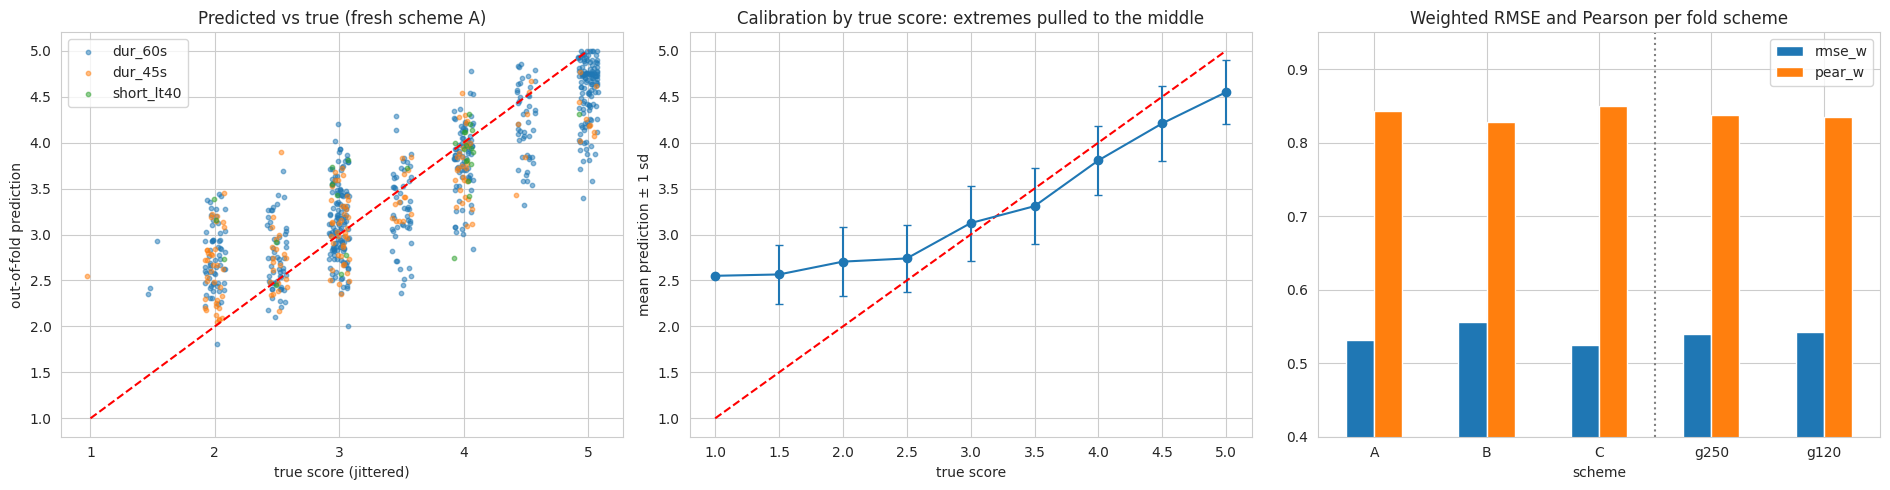

In [10]:
o = FINAL['A']
fig, ax = plt.subplots(1, 3, figsize=(19, 5))
for g, c in [('dur_60s', 'tab:blue'), ('dur_45s', 'tab:orange'), ('short_lt40', 'tab:green')]:
    m = nz & (grp == g)
    ax[0].scatter(y[m] + np.random.RandomState(0).uniform(-0.08, 0.08, m.sum()), o[m], s=10, alpha=0.5, c=c, label=g)
ax[0].plot([1, 5], [1, 5], 'r--'); ax[0].set_xlabel('true score (jittered)'); ax[0].set_ylabel('out-of-fold prediction')
ax[0].set_title('Predicted vs true (fresh scheme A)'); ax[0].legend()

d = pd.DataFrame({'y': y[nz], 'p': o[nz]})
b = d.groupby('y').p.agg(['mean', 'std', 'count'])
ax[1].errorbar(b.index, b['mean'], yerr=b['std'], fmt='o-', capsize=3)
ax[1].plot([1, 5], [1, 5], 'r--'); ax[1].set_xlabel('true score'); ax[1].set_ylabel('mean prediction ± 1 sd')
ax[1].set_title('Calibration by true score: extremes pulled to the middle')

M_ = RES.loc[FRESH + SEL, ['rmse_w', 'pear_w']]
M_.plot.bar(ax=ax[2], rot=0); ax[2].set_ylim(0.4, 0.95)
ax[2].set_title('Weighted RMSE and Pearson per fold scheme'); ax[2].axvline(2.5, c='gray', ls=':')
plt.tight_layout(); plt.show()

## 8. Ablations

All rows are computed live on the same five fold schemes. "Δ vs final" is the change in fresh-fold proxy (positive means worse than the final model). The summary printed under the table is generated from the numbers.

What the table shows (final model: fresh-fold proxy 0.349):

* **Audio and transcript views complement each other.** The best single head is the Whisper encoder (0.384). Audio-only (W + H) reaches 0.382 and transcript-only (M7 + M14) 0.405; together they reach 0.349.
* **Not every head pulls its weight.** Dropping the Whisper encoder (+0.016) or WavLM (+0.008) clearly hurts. Dropping the 7B head costs only +0.002, and dropping the 14B head costs +0.001 and is even better on 2 of 3 fresh schemes. The two LLM heads carry largely the same information, so **the 14B head is close to redundant**. I did not remove it after seeing this, because that would be a choice made on the fresh folds themselves; I note it as the first simplification for a production version (it also saves the most expensive LLM pass, Section 12).
* **Ridge + SVR.** The mix is clearly better than ridge-only (+0.010 for ridge-only, worse on all three schemes), and about equal to SVR-only (+0.0005).
* **The text-feature model does not help on CV.** A ridge model on 93 hand-made features (ASR confidence, pauses, LanguageTool error rates, GPT-2 perplexity, LLM zero-shot scores) is weak alone (0.470) and makes the blend 0.003 worse. It scored slightly better on the public leaderboard (0.3662 against 0.3700), a difference inside the leaderboard noise. I kept it as the second (hedge) submission and left it out of the primary model, which also removes the dependency on ASR confidence scores (Section 11).

text-feature matrix: (769, 93)
                                              A       B       C    g250    g120  fresh mean  Δ vs final (fresh)  fresh wins vs final  RMSE_w (A)  Pearson_w (A)
model                                                                                                                                                          
FINAL: W + H + M7 + M14 (ridge+SVR)      0.3440  0.3643  0.3378  0.3513  0.3540      0.3487              0.0000                    0      0.5315         0.8435
single head: W                           0.4117  0.4397  0.3998  0.4137  0.4256      0.4171              0.0684                    0      0.6081         0.7847
single head: H                           0.3790  0.3995  0.3725  0.3862  0.3861      0.3837              0.0350                    0      0.5677         0.8097
single head: M7                          0.4077  0.4276  0.4041  0.4138  0.4146      0.4131              0.0644                    0      0.6002         0.7849
single he

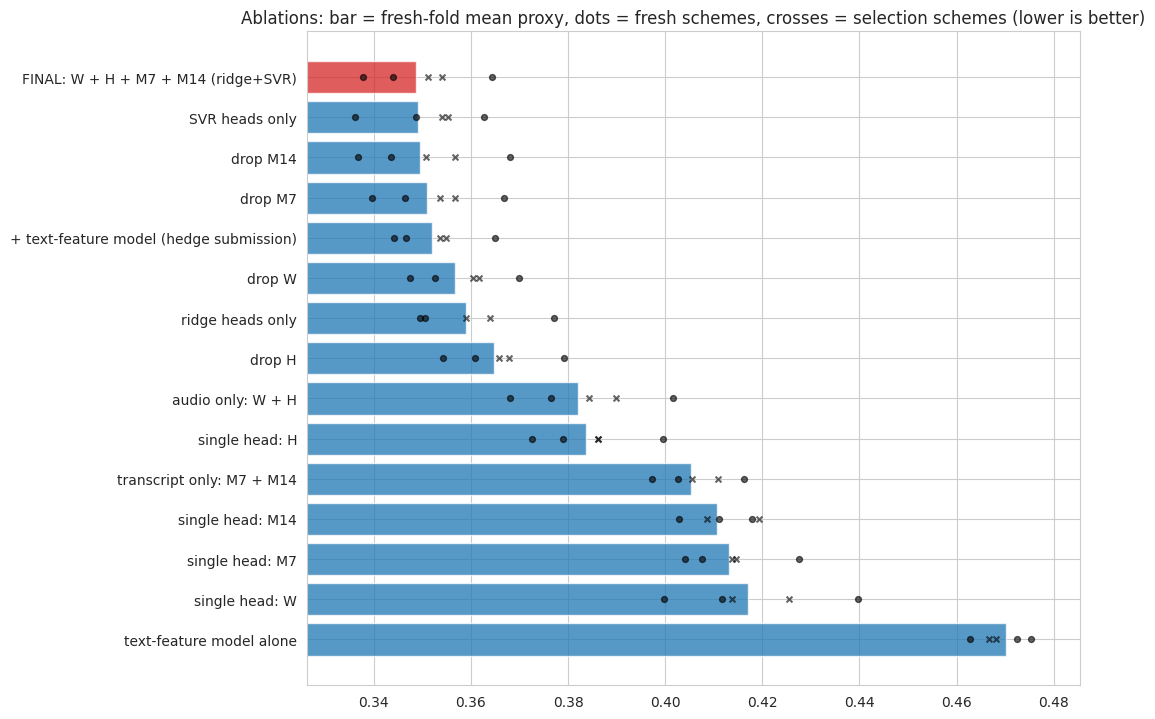

In [11]:
# optional text-feature head, only if those inputs are attached
tf_path, ls_path, q_path = find('text_features.csv', False), find('llm_scores.csv', False), find('llm14_scores.csv', False)
HAS_TEXT = all([tf_path, ls_path, q_path])
if HAS_TEXT:
    TF = pd.read_csv(tf_path, index_col='uid')
    LS = pd.read_csv(ls_path).set_index('uid')
    QS = pd.read_csv(q_path).set_index('uid')
    lcols = ['e', 'ent'] + [f'p{k}' for k in range(1, 6)] + [f'l{k}' for k in range(1, 6)]
    qcols = ['e', 'ent', 'p1', 'p2', 'p3', 'p4', 'p5']
    tm = lambda u: np.hstack([TF.loc[u].values, LS.loc[u, lcols].values, QS.loc[u, qcols].values]).astype(np.float32)
    FEAT['TL'] = (tm(tr_uids), tm(te_uids))
    print('text-feature matrix:', FEAT['TL'][0].shape)
else:
    print('text-feature inputs not attached: the text ablation rows are skipped')

ABL = {'FINAL: W + H + M7 + M14 (ridge+SVR)': (TAGS, 'mix'),
       'single head: W': (['W'], 'mix'), 'single head: H': (['H'], 'mix'),
       'single head: M7': (['M7'], 'mix'), 'single head: M14': (['M14'], 'mix'),
       'audio only: W + H': (['W', 'H'], 'mix'), 'transcript only: M7 + M14': (['M7', 'M14'], 'mix'),
       'drop W': (['H', 'M7', 'M14'], 'mix'), 'drop H': (['W', 'M7', 'M14'], 'mix'),
       'drop M7': (['W', 'H', 'M14'], 'mix'), 'drop M14': (['W', 'H', 'M7'], 'mix'),
       'ridge heads only': (TAGS, 'ridge'), 'SVR heads only': (TAGS, 'svr')}
if HAS_TEXT:
    ABL['+ text-feature model (hedge submission)'] = (TAGS + ['TL'], 'mix')
    ABL['text-feature model alone'] = (['TL'], 'mix')

t0 = time.time()
ref = proxies(TAGS)
rows = []
for name, (tags, kind) in ABL.items():
    p = proxies(tags, kind)
    sA = score(blend(tags, 'A', kind))
    rows.append({'model': name, **{s: p[s] for s in ALL_S}, 'fresh mean': np.mean([p[s] for s in FRESH]),
                 'Δ vs final (fresh)': np.mean([p[s] - ref[s] for s in FRESH]),
                 'fresh wins vs final': int(sum(p[s] < ref[s] for s in FRESH)),
                 'RMSE_w (A)': sA['rmse_w'], 'Pearson_w (A)': sA['pear_w']})
ABLT = pd.DataFrame(rows).set_index('model')
print(ABLT.round(4).to_string())
print(f'({(time.time() - t0) / 60:.1f} min)')

print('\nSummary (fresh-fold mean proxy, final =', round(ABLT.loc['FINAL: W + H + M7 + M14 (ridge+SVR)', 'fresh mean'], 4), ')')
for name in ABLT.index[1:]:
    dd, wins = ABLT.loc[name, 'Δ vs final (fresh)'], ABLT.loc[name, 'fresh wins vs final']
    verdict = 'worse' if dd > 0.003 else ('better' if dd < -0.003 else 'about the same')
    print(f'  {name:42s} {verdict:15s} (Δ {dd:+.4f}, better on {wins}/3 fresh schemes)')

fig, ax = plt.subplots(figsize=(11, 0.42 * len(ABLT) + 1))
order = ABLT.sort_values('fresh mean', ascending=False)
ax.barh(order.index, order['fresh mean'], color=['tab:red' if i.startswith('FINAL') else 'tab:blue' for i in order.index], alpha=0.75)
for s, mk in zip(ALL_S, ['o', 'o', 'o', 'x', 'x']):
    ax.scatter(order[s], order.index, s=18, marker=mk, c='k', alpha=0.6)
ax.set_xlim(order[ALL_S].min().min() - 0.01, order[ALL_S].max().max() + 0.01)
ax.set_title('Ablations: bar = fresh-fold mean proxy, dots = fresh schemes, crosses = selection schemes (lower is better)')
plt.tight_layout(); plt.show()

### Development history (public leaderboard)

| Version | What changed | CV proxy (selection folds) | Public LB |
|---|---|---|---|
| v1 | WavLM layer 21, ridge | 0.425 | 0.4182 |
| v2 | + 74 text features (ASR timing and confidence, LanguageTool, GPT-2) | 0.405 | 0.4114 |
| v3 | + Whisper encoder layer 30 | 0.387 | 0.3883 |
| v4 | + Qwen 7B zero-shot scores and last-token state, text without ASR confidence | 0.375 | 0.3770 |
| v5 | + Qwen 7B mean-pooled transcript states, extra prompt views | 0.362 | 0.3673 |
| v6 | + SVR heads, + Qwen 14B, text model kept (**hedge submission**) | 0.354 | **0.3662** |
| v6 no-text | same, text model removed (**primary submission**) | 0.353 (fresh 0.349) | 0.3700 |

CV and public LB moved in the same direction at every step up to v6. Each version was chosen by CV before it was submitted. The last two versions differ by 0.004 on the public LB, in opposite order to CV; at about 130 public files that difference is not meaningful, so the primary choice stays with CV.

## 9. What did not work

Each idea below was judged by the same pre-registered rule on the fresh folds (numbers from my experiment notebooks `shl-07`, `shl-10`, `shl-12`, `shl-14`, `shl-16`, `shl-17`, `shl-18`). Δ is the change in fresh-fold proxy; positive is worse.

| Idea | Why I expected it to help | Result |
|---|---|---|
| Add HuBERT-Large (best layer 20) | another self-supervised audio view | Δ +0.001, 0/3 schemes better. Alone it is much weaker (0.455 vs 0.40 for Whisper) |
| Add wav2vec2-Large (layer 14, mean+std) | same | Δ +0.008, 0/3. Weak heads pull an equal-weight average down |
| Average a band of layers instead of one | smoother representation | worse for WavLM (0.447 vs 0.425), equal for Whisper |
| Mean + std pooling over time | variability of speech (pausing, hesitation) | Δ between −0.0003 and +0.0004: no effect |
| Up-weight 45 s clips in training (√ of test weight) | match the test mix | Δ −0.0003, 1/3: no effect |
| Linear re-calibration of the blend (predictions are compressed, slope ≈ 1.14) | lower RMSE | Δ −0.0024 but only 2/3 schemes, and worse on the selection folds. Rejected; the slope varies by fold |
| Qwen 7B on a literal CTC transcript (wav2vec2-960h, no language model) | Whisper may silently fix the speaker's grammar | Δ +0.002 to +0.003, 0/3. The literal transcript is noisy and much weaker on 45 s clips (zero-shot Spearman 0.43 vs 0.66) |
| Qwen 14B instead of 7B zero-shot | bigger judge | Spearman with labels 0.634 vs 0.622; no real gain |
| Last-token LLM state | standard way to read an LLM | 0.461 vs 0.422 for mean-pooling over the transcript |
| LightGBM on text features | non-linear interactions | 0.541 vs 0.515 for ridge |
| Learned (stacked) blend weights | let the data weight the heads | better on g250, worse on g120; equal weights are more stable |

The pattern: once the four strong views were in, more of the same kind of information stopped helping, and the remaining error looks dominated by label noise and the small number of 45 s training clips (154).

## 10. Error analysis

The main systematic error is **shrinkage toward the middle**: the model under-scores strong speakers and over-scores weak ones. Speakers rated 2.0 are predicted 2.7 on average, and speakers rated 5.0 are predicted 4.55. A regression of the true score on the prediction has a slope of 1.12 to 1.14 on every fold scheme, and the spread of test predictions (sd 0.78) is smaller than the spread of the labels (sd 1.01). More than half of the 25 largest errors are speakers rated 2.0. In a hiring context this matters more than the average error: the candidates at the two ends are exactly the ones a decision depends on. A simple re-stretch did not pass my validation rule (Section 9), so I report the effect rather than patch it.

In [12]:
o = FINAL['A']
d = pd.DataFrame({'y': y[nz], 'p': o[nz], 'g': grp[nz]})
d['err'] = d.p - d.y
by = d.groupby('y').agg(n=('p', 'size'), mean_pred=('p', 'mean'), bias=('err', 'mean'), rmse=('err', lambda e: np.sqrt(np.mean(e ** 2))))
print('Out-of-fold errors by true score (scheme A):')
print(by.round(3))
print('\nslope of true score on prediction, per scheme (1 = well calibrated, > 1 = predictions compressed):')
print({s: round(float(np.polyfit(FINAL[s][nz], y[nz], 1)[0]), 3) for s in ALL_S})
print(f'\nspread: test predictions sd {np.std(pred_te[~rule_te]):.3f} | OOF predictions sd {np.std(o[nz]):.3f} | labels sd {np.std(y[nz]):.3f}')
big = d.assign(abs_err=d.err.abs()).sort_values('abs_err', ascending=False).head(25)
print('\n25 largest errors: share by true score', big.y.value_counts().sort_index().to_dict(),
      '| by group', big.g.value_counts().to_dict())

Out-of-fold errors by true score (scheme A):
       n  mean_pred   bias   rmse
y                                
1.0    1      2.551  1.551  1.551
1.5    3      2.566  1.066  1.097
2.0  102      2.705  0.705  0.796
2.5   79      2.740  0.240  0.434
3.0  174      3.124  0.124  0.426
3.5   64      3.309 -0.191  0.449
4.0  124      3.807 -0.193  0.422
4.5   52      4.209 -0.291  0.497
5.0  133      4.549 -0.451  0.568

slope of true score on prediction, per scheme (1 = well calibrated, > 1 = predictions compressed):
{'A': 1.133, 'B': 1.121, 'C': 1.137, 'g250': 1.12, 'g120': 1.118}

spread: test predictions sd 0.781 | OOF predictions sd 0.767 | labels sd 1.014

25 largest errors: share by true score {1.0: 1, 1.5: 1, 2.0: 14, 2.5: 2, 3.0: 1, 4.0: 1, 5.0: 5} | by group {'dur_60s': 17, 'dur_45s': 6, 'short_lt40': 2}


## 11. Fairness and robustness

I have no demographic information (accent, first language, gender, age), so I cannot measure fairness across those groups directly. What I can check is whether the model's **errors** depend on things that should not affect a grammar score: recording length, loudness, how much of the clip is speech, how confident the ASR was (a rough proxy for accent and audio quality) and speaking rate.

The test is the Spearman correlation between the residual (prediction minus label) and each variable. A variable can legitimately correlate with the *label*; a problem is when it correlates with the *error*, because then the model rewards or penalises it beyond what the raters did.

One trap: because predictions are compressed (Section 10), the residual is itself negatively correlated with the label. Any variable that tracks the label will therefore look correlated with the error. So the deciding column compares speakers **with the same label**: the residual is centred within each label value before correlating.

Design choices made for this reason:

* **The primary model uses no ASR confidence features.** Word probabilities from Whisper were among the strongest hand-made features (Spearman up to 0.68 with the label), but low ASR confidence is also what an unfamiliar accent or a poor microphone produces. A grammar score should not depend on that. Removing them cost little, and the final model does not use them at all.
* **The ASR transcript is still in the pipeline** (the two LLM heads read it). If Whisper transcribes some accents less accurately, those speakers may be scored differently. This is the main residual risk, and I list it under next steps.
* **Duration groups** are monitored separately, because 45 s clips are the majority of test and the minority of train.

If a variable is flagged in the table below (same-label column), the model's errors still track it, even without using it as an input.

**What the check found.** Duration, loudness and the share of speech show no meaningful same-label effect. Two variables are flagged:

* **ASR word confidence: ρ ≈ +0.28.** Among speakers with the same human score, those whose speech Whisper recognised more confidently are scored higher by the model. Low ASR confidence comes from unfamiliar accents, background noise and poor microphones, so these speakers are the ones likely to be under-scored.
* **Speaking rate: ρ ≈ +0.16.** Faster speakers are scored somewhat higher than slower speakers with the same human score. Raters were asked to judge grammar, not fluency; the model partly rewards fluency.

The model does not use either variable as an input. The audio embeddings carry clarity and fluency, and the LLM heads read a transcript whose quality depends on the same factors. Without demographic data I cannot say which groups are affected, but this is exactly the pattern that would disadvantage non-native accents. I would treat it as a blocking item before any real use (Section 14).

Per duration group (scheme A):
              n  mean_label  mean_pred   bias   rmse  pearson
group                                                        
dur_45s     154       3.091      3.176  0.085  0.530    0.823
dur_60s     549       3.589      3.571 -0.018  0.533    0.861
short_lt40   29       3.500      3.596  0.096  0.552    0.694

Do errors depend on nuisance variables? (residual = prediction - label, speech files, scheme A)
                            Spearman with label  with residual  with residual, same label  p (same label)   flag
variable                                                                                                        
duration (s)                              0.142         -0.059                      0.064           0.084       
loudness (rms dB)                         0.099         -0.055                      0.033           0.370       
speech ratio                              0.062         -0.041                     -0.004           0.912     

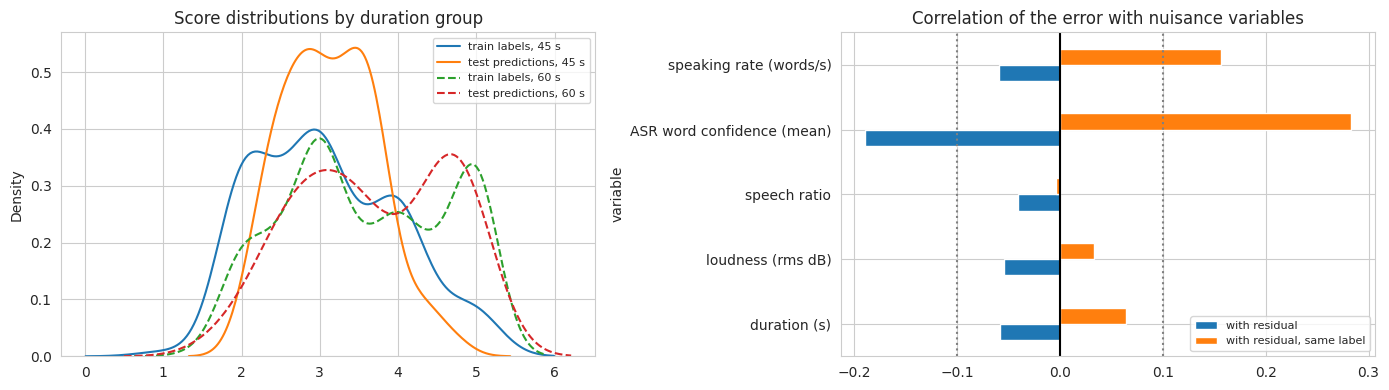

In [13]:
o = FINAL['A']
res_ = o - y
rows = []
for g in ['dur_45s', 'dur_60s', 'short_lt40']:
    m = nz & (grp == g)
    if m.sum() > 5:
        rows.append(dict(group=g, n=int(m.sum()), mean_label=y[m].mean(), mean_pred=o[m].mean(), bias=res_[m].mean(),
                         rmse=rmse(y[m], o[m]), pearson=pear(y[m], o[m])))
print('Per duration group (scheme A):')
print(pd.DataFrame(rows).set_index('group').round(3))

nuis = {'duration (s)': dur_tr, 'loudness (rms dB)': meta.loc[tr_uids, 'rms_db'].values,
        'speech ratio': meta.loc[tr_uids, 'speech_ratio'].values}
if HAS_TEXT:
    nuis['ASR word confidence (mean)'] = TF.loc[tr_uids, 'wp_mean'].values
    nuis['speaking rate (words/s)'] = TF.loc[tr_uids, 'wps_span'].values
res_c = res_ - pd.Series(res_).groupby(y).transform('mean').values     # residual compared within the same label
rows = []
for k, v in nuis.items():
    m = nz & np.isfinite(v)
    r1, _ = spearmanr(v[m], y[m])
    r2, _ = spearmanr(v[m], res_[m])
    r3, p3 = spearmanr(v[m], res_c[m])
    rows.append({'variable': k, 'Spearman with label': r1, 'with residual': r2,
                 'with residual, same label': r3, 'p (same label)': p3,
                 'flag': 'check' if (abs(r3) >= 0.10 and p3 < 0.01) else ''})
FAIR = pd.DataFrame(rows).set_index('variable')
print('\nDo errors depend on nuisance variables? (residual = prediction - label, speech files, scheme A)')
print(FAIR.round(3))
print('Reading: compare speakers with the same label (third column). A positive value means higher values of the variable are '
      'over-scored relative to the raters; a negative value means they are under-scored.')
flag = FAIR.index[FAIR.flag == 'check'].tolist()
print('variables flagged (same-label |rho| >= 0.10 and p < 0.01):', flag if flag else 'none')

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.kdeplot(x=y[nz & (grp == 'dur_45s')], ax=ax[0], label='train labels, 45 s')
sns.kdeplot(x=pred_te[te_grp == 'dur_45s'], ax=ax[0], label='test predictions, 45 s')
sns.kdeplot(x=y[nz & (grp == 'dur_60s')], ax=ax[0], label='train labels, 60 s', ls='--')
sns.kdeplot(x=pred_te[te_grp == 'dur_60s'], ax=ax[0], label='test predictions, 60 s', ls='--')
ax[0].set_title('Score distributions by duration group'); ax[0].legend(fontsize=8)
FAIR[['with residual', 'with residual, same label']].plot.barh(ax=ax[1])
ax[1].axvline(0, c='k'); ax[1].axvline(0.1, c='gray', ls=':'); ax[1].axvline(-0.1, c='gray', ls=':')
ax[1].set_title('Correlation of the error with nuisance variables')
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 12. Cost and deployment

Measured on Kaggle T4 GPUs during feature extraction (per 45 to 60 s recording). The regression heads train in under a minute on CPU and predict in milliseconds.

| Component | GPU time per recording | Needed by |
|---|---|---|
| Whisper large-v3 ASR (faster-whisper, beam 5, word timings) | ~3.6 s | M7, M14 |
| WavLM-Large | ~1.2 s | W |
| Whisper-large-v3 encoder | ~0.4 s | H |
| Qwen2.5-7B, one forward pass | ~0.4 s | M7 |
| Qwen2.5-14B 8-bit, one forward pass | ~0.8 s | M14 |
| **Total** | **~6.4 s** | |

The ablation table gives the quality cost of cheaper variants:

* **Drop the 14B head:** saves ~0.8 s per recording for a fresh-fold proxy change of +0.001. This is the obvious first simplification.
* **Audio only (W + H):** ~1.6 s per recording and no ASR or LLM, at a cost of +0.033 in proxy (Pearson about 0.81 instead of 0.84 on the test mix). For high-volume screening that may be acceptable, with the full model reserved for borderline scores. ASR dominates the cost, and it is shared with any other text-based scoring (vocabulary, content), so in a product it would usually already be paid for.

## 13. Submission

The primary submission is the four-head model. The hedge adds the text-feature model (requires the text inputs). Both are checked against the format of `test.csv`.

In [14]:
def check_and_save(pred, path):
    sub = pd.DataFrame({'filename': test.filename, 'label': pred})
    assert len(sub) == len(test) and sub.filename.is_unique and sub.label.notna().all()
    assert set(sub.filename) == set(test.filename)
    assert ((sub.label >= 1) & (sub.label <= 5) | (sub.label == 0)).all()
    sub.to_csv(path, index=False)
    print(f'saved {path} | {sub.shape} | ', sub.label.describe()[['mean', 'std', 'min', 'max']].round(3).to_dict())
    return sub

primary = check_and_save(pred_te, f'{WORK}/submission.csv')
print('reference, the submitted primary file had mean 3.305, std 0.783, min 1.729, max 4.98 (public LB 0.3700)')
if HAS_TEXT:
    m = make_pipeline(SimpleImputer(strategy='median'), Winsor(), StandardScaler(), RidgeCV(alphas=np.logspace(-1, 4, 12)))
    tl_te = np.clip(m.fit(FEAT['TL'][0][nz], y[nz]).predict(FEAT['TL'][1]), 1, 5)
    hedge_pred = np.where(rule_te, 0.0, (np.mean([FIT[t][1] for t in TAGS], 0) * 4 + tl_te) / 5)
    hedge = check_and_save(hedge_pred, f'{WORK}/submission_with_text.csv')
    print(f'correlation between primary and hedge test predictions: {pear(primary.label, hedge.label):.4f} (public LB of hedge: 0.3662)')
print(f'\nwhole notebook ran in {(time.time() - T_START) / 60:.1f} min')

saved /kaggle/working/submission.csv | (216, 2) |  {'mean': 3.305, 'std': 0.783, 'min': 1.729, 'max': 4.98}
reference, the submitted primary file had mean 3.305, std 0.783, min 1.729, max 4.98 (public LB 0.3700)
saved /kaggle/working/submission_with_text.csv | (216, 2) |  {'mean': 3.311, 'std': 0.761, 'min': 1.763, 'max': 4.945}
correlation between primary and hedge test predictions: 0.9955 (public LB of hedge: 0.3662)

whole notebook ran in 5.4 min


## 14. Limitations and next steps

**Limitations**

* **Small data.** 732 speech recordings, of which only 154 are 45 s clips, the format that makes up two-thirds of test. Every estimate here has an uncertainty of roughly ±0.02 in proxy terms.
* **Leaderboard noise.** The public LB uses about 130 recordings; differences below about 0.01 cannot be trusted, and the final ranking uses the other 40 %.
* **Compressed predictions.** Strong and weak speakers are pulled toward the middle (Section 10).
* **ASR in the loop.** The LLM heads score Whisper's transcript, not the raw speech. Whisper's tendency to normalise disfluent or ungrammatical speech, and possible accent-dependent errors, flow into the score.
* **Frozen features.** No model was fine-tuned for this task; everything is a read-out of pre-trained representations.

**What I would do next**

1. **Parameter-efficient fine-tuning (LoRA) of the LLM** to predict the score from the transcript directly, with the same grouped CV. This is the most likely source of a large gain and also the most likely to overfit 732 examples, so it needs the fresh-fold discipline used here.
2. **Fine-tune a speech encoder end to end** (Whisper encoder with a small regression head), with strong regularisation.
3. **Calibrate for decisions, not RMSE.** Fit the stretch on a held-out set, and report score bands with uncertainty so that borderline candidates go to a human rater.
4. **Fix and audit the clarity and fluency effect found in Section 11.** Options to test with the same fresh-fold discipline: adding ASR confidence and speaking rate as explicit inputs and then removing their linear effect from the score, or training with a penalty on the correlation between residual and these variables. Then audit by accent and first language with consented demographic data, including ASR word-error rate by group.
5. **Rater noise.** With access to individual rater scores, estimate inter-rater agreement; it sets the ceiling for any model and tells us how much of the remaining error is reachable.

---
*Reproducibility:* fixed seeds (42 for folds and PCA, 0 for SVR PCA, 7/11/23 for the fresh schemes); scikit-learn models only after feature extraction; Kaggle Python image, October 2026. All experiment notebooks (`shl-01` to `shl-18`) are in the repository under `experiments/` with outputs removed.